In [ ]:
# 1. 나눔폰트 설치 (실행 후 세션 재시작)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt

# 2. 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 3. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,381 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

🎓 조선시대 문집 문체 분석기 (생몰년 검색 버전)

찾으시는 저자의 생년과 몰년을 입력해 주세요.
(예: 1800 1870, 종료하려면 q 입력)
>> 입력: 1731 1783

✅ 총 3건이 검색되었습니다.
------------------------------------------------------------
Index    제목                   생년     몰년     활동연대      
------------------------------------------------------------
1536     芝村遺集                 1730   1783   1756.5
1546     湛軒書                  1731   1783   1757.0
1547     湛軒書(內集)              1731   1783   1757.0
------------------------------------------------------------

📊 분석하고 싶은 문집의 [Index] 번호를 입력하세요.
>> Index 입력: 1546

📑 [湛軒書] 분석 리포트
• 저자 생몰: 1731 ~ 1783
• 비교군: 동시대(±20년) 문집 255종 평균
------------------------------------------------------------
문체         내 문집       동시대 평균       차이        
------------------------------------------------------------
公車類           0.0%        2.5% 🔻 2.5%p
書簡類          22.6%       15.3% 🔺 7.3%p
序跋類           6.3%        5.1% 🔺 1.3%p
詩類           10.9%       57.9% 🔻 47.0%p
哀祭類           4.1%        7.4% 🔻 3.4%p
雜著類       

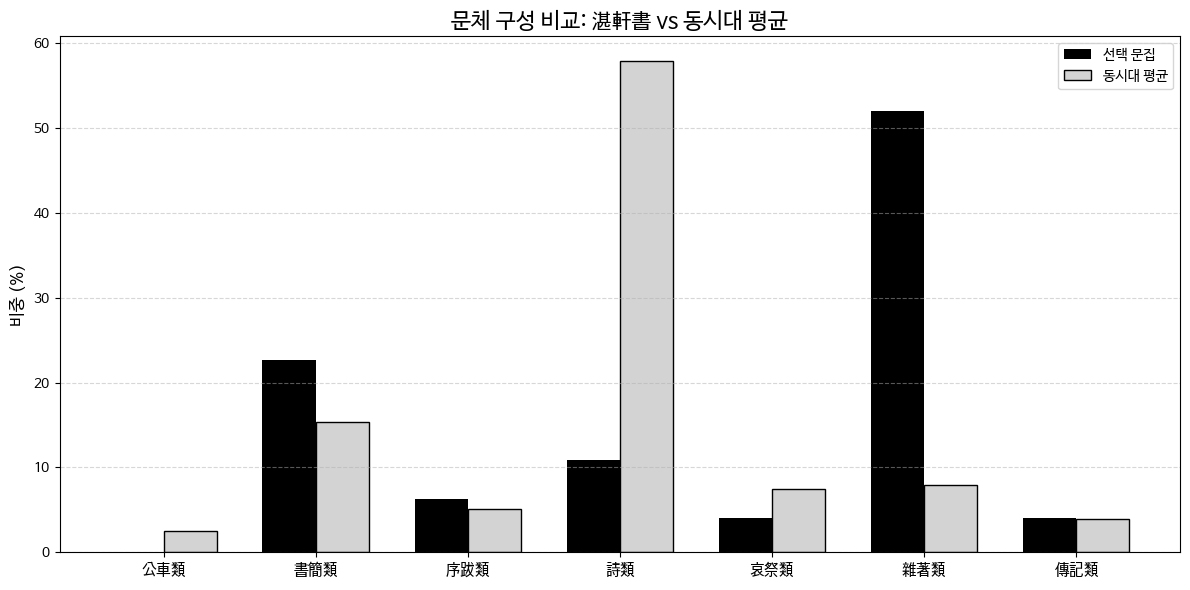


✨ 분석이 완료되었습니다!


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 초기 설정 (데이터 로드 & 폰트)
# ==========================================
df = pd.read_csv('Dataset_Munzip_Genre.csv')

# 폰트 설정 (Colab용)
import matplotlib.font_manager as fm
import os

# 나눔폰트 설치 여부 확인 및 설정 (Colab 환경 대응)
if os.path.exists('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'):
    plt.rc('font', family='NanumBarunGothic')
else:
    # 로컬 환경(윈도우/맥)용
    import platform
    system_name = platform.system()
    if system_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    elif system_name == 'Darwin':
        plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리
cols = ['생년', '몰년', '公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類', 'SUM']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['생년', '몰년', 'SUM'])
df['Activity_Year'] = (df['생년'] + df['몰년']) / 2

styles = ['公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類']
for style in styles:
    df[f'{style}_Ratio'] = (df[style] / df['SUM']) * 100

# ==========================================
# 2. 대화형 분석 함수
# ==========================================

def run_interactive_analysis():
    print("="*60)
    print("🎓 조선시대 문집 문체 분석기 (생몰년 검색 버전)")
    print("="*60)

    # [Step 1] 생몰년 입력 받기
    while True:
        try:
            print("\n찾으시는 저자의 생년과 몰년을 입력해 주세요.")
            print("(예: 1800 1870, 종료하려면 q 입력)")
            user_input = input(">> 입력: ")

            if user_input.lower() == 'q':
                print("프로그램을 종료합니다.")
                return

            birth, death = map(int, user_input.split())

            # 오차 범위 설정 (기본값 ±2년)
            tolerance = 2
            mask = (df['생년'] >= birth - tolerance) & (df['생년'] <= birth + tolerance) & \
                   (df['몰년'] >= death - tolerance) & (df['몰년'] <= death + tolerance)
            results = df[mask][['제목', '생년', '몰년', 'Activity_Year']]

            if len(results) == 0:
                print(f"❌ 검색 결과가 없습니다. (오차 ±{tolerance}년 내)")
                print("다시 입력해 주세요.")
                continue

            print(f"\n✅ 총 {len(results)}건이 검색되었습니다.")
            print("-" * 60)
            print(f"{'Index':<8} {'제목':<20} {'생년':<6} {'몰년':<6} {'활동연대':<10}")
            print("-" * 60)
            for idx, row in results.iterrows():
                print(f"{idx:<8} {row['제목']:<20} {int(row['생년']):<6} {int(row['몰년']):<6} {row['Activity_Year']:.1f}")
            print("-" * 60)
            break

        except ValueError:
            print("⚠️ 잘못된 형식입니다. 숫자 두 개를 띄어쓰기로 구분해서 입력해주세요.")

    # [Step 2] 분석할 Index 입력 받기
    while True:
        try:
            print("\n📊 분석하고 싶은 문집의 [Index] 번호를 입력하세요.")
            target_idx = int(input(">> Index 입력: "))

            if target_idx not in results.index:
                print("⚠️ 검색 결과에 없는 번호입니다. 다시 확인해주세요.")
                continue

            # [Step 3] 분석 실행
            target = df.loc[target_idx]
            my_year = target['Activity_Year']
            window = 20
            peers = df[
                (df['Activity_Year'] >= my_year - window) &
                (df['Activity_Year'] <= my_year + window)
            ]

            my_ratios = [target[f'{style}_Ratio'] for style in styles]
            peer_means = [peers[f'{style}_Ratio'].mean() for style in styles]

            # [Step 4] 결과 리포트 출력
            print("\n" + "="*60)
            print(f"📑 [{target['제목']}] 분석 리포트")
            print("="*60)
            print(f"• 저자 생몰: {int(target['생년'])} ~ {int(target['몰년'])}")
            print(f"• 비교군: 동시대(±{window}년) 문집 {len(peers)}종 평균")
            print("-" * 60)

            # 텍스트 비교
            print(f"{'문체':<10} {'내 문집':<10} {'동시대 평균':<12} {'차이':<10}")
            print("-" * 60)
            for style, my, peer in zip(styles, my_ratios, peer_means):
                diff = my - peer
                mark = "🔺" if diff > 0 else "🔻"
                print(f"{style:<10} {my:>6.1f}% {peer:>10.1f}% {mark} {abs(diff):.1f}%p")
            print("-" * 60)

            # 그래프 그리기
            x = np.arange(len(styles))
            width = 0.35

            plt.figure(figsize=(12, 6))
            plt.bar(x - width/2, my_ratios, width, label='선택 문집', color='black')
            plt.bar(x + width/2, peer_means, width, label='동시대 평균', color='lightgray', edgecolor='black')

            plt.xticks(x, styles, fontsize=12)
            plt.ylabel('비중 (%)', fontsize=12)
            plt.title(f'문체 구성 비교: {target["제목"]} vs 동시대 평균', fontsize=16)
            plt.legend()
            plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

            print("\n✨ 분석이 완료되었습니다!")
            break

        except ValueError:
             print("⚠️ 숫자로 입력해주세요.")

# ==========================================
# 3. 프로그램 실행
# ==========================================
run_interactive_analysis()